# Diagnostic Analysis - RNA Template-Based Modeling

このノートブックでは、テンプレートベースモデリング手法の診断的分析を行います。

## 目的
- 現状手法の課題を定量的に把握
- 各処理ステップの効果を測定
- 次世代ロジック開発の方向性を決定

## セットアップ

In [12]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [13]:
# Load diagnostic log
diag_path = Path('diagnostics/prediction_log.jsonl')
if not diag_path.exists():
    raise FileNotFoundError(f'Diagnostic log not found: {diag_path}. Please run run_diagnostic.ipynb first.')

diag_logs = []
with open(diag_path) as f:
    for line in f:
        if line.strip():
            diag_logs.append(json.loads(line))

diag_df = pd.DataFrame(diag_logs)
print(f'Loaded {len(diag_df)} diagnostic logs')
diag_df.head()

Loaded 28 diagnostic logs


,query_id,query_length,template_id,seq_identity,used_local_align,kabsch_applied,raw_coverage,final_coverage
0,8ZNQ,30,1MFY,0.645161,False,True,0.666667,0.666667
1,9IWF,69,3IVN,0.742857,False,True,0.753623,0.753623
2,9JGM,210,6CC1,0.695238,False,False,0.647619,0.647619
3,9MME,4640,4V5H,0.657112,False,False,0.656681,0.656681
4,9J09,214,4GMA,0.649533,False,False,0.602804,0.602804


In [14]:
# Load evaluation results (RMSD)
eval_path = Path('validation_rmsd_results.csv')
if eval_path.exists():
    eval_df = pd.read_csv(eval_path)
    # Merge with diagnostic logs
    df = diag_df.merge(eval_df[['target_id', 'mean_rmsd', 'median_rmsd', 'n_matched']], 
                       left_on='query_id', right_on='target_id', how='left')
    print(f'Merged with evaluation results: {len(df)} records')
else:
    print('Warning: Evaluation results not found. Using diagnostic logs only.')
    df = diag_df.copy()
    df['mean_rmsd'] = None

df.head()

Merged with evaluation results: 28 records


,query_id,query_length,template_id,seq_identity,used_local_align,kabsch_applied,raw_coverage,final_coverage,target_id,mean_rmsd,median_rmsd,n_matched
0,8ZNQ,30,1MFY,0.645161,False,True,0.666667,0.666667,8ZNQ,12.723722,12.475699,30
1,9IWF,69,3IVN,0.742857,False,True,0.753623,0.753623,9IWF,22.769798,21.207528,69
2,9JGM,210,6CC1,0.695238,False,False,0.647619,0.647619,9JGM,47.473231,39.695289,210
3,9MME,4640,4V5H,0.657112,False,False,0.656681,0.656681,9MME,109.233749,100.225911,4168
4,9J09,214,4GMA,0.649533,False,False,0.602804,0.602804,9J09,34.852585,31.825562,114


## セクション1: 全体サマリー

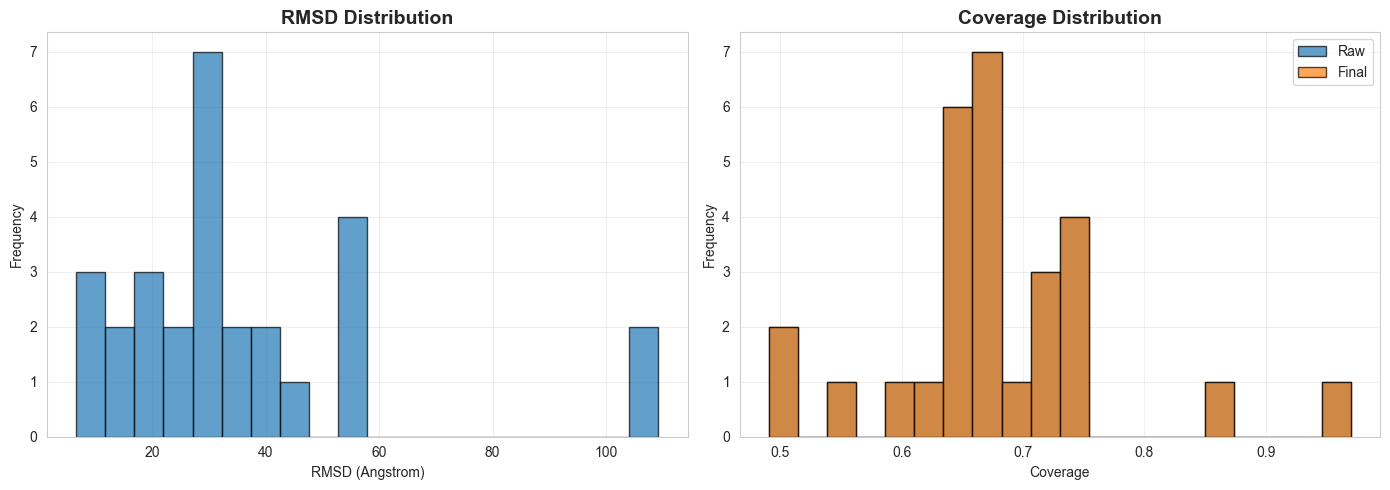

In [15]:
# RMSD distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
if 'mean_rmsd' in df.columns and df['mean_rmsd'].notna().any():
    axes[0].hist(df['mean_rmsd'].dropna(), bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_title('RMSD Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('RMSD (Angstrom)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No RMSD data available', ha='center', va='center', transform=axes[0].transAxes)

# Coverage distribution
if 'raw_coverage' in df.columns:
    axes[1].hist(df['raw_coverage'].dropna(), bins=20, edgecolor='black', alpha=0.7, label='Raw')
if 'final_coverage' in df.columns:
    axes[1].hist(df['final_coverage'].dropna(), bins=20, edgecolor='black', alpha=0.7, label='Final')
axes[1].set_title('Coverage Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coverage')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Basic statistics
print('='*60)
print('SUMMARY STATISTICS')
print('='*60)

if 'mean_rmsd' in df.columns and df['mean_rmsd'].notna().any():
    print(f"\nRMSD (Angstrom):")
    print(f"  Mean:   {df['mean_rmsd'].mean():.2f}")
    print(f"  Median: {df['mean_rmsd'].median():.2f}")
    print(f"  Min:    {df['mean_rmsd'].min():.2f}")
    print(f"  Max:    {df['mean_rmsd'].max():.2f}")

if 'raw_coverage' in df.columns:
    print(f"\nRaw Coverage:")
    print(f"  Mean:   {df['raw_coverage'].mean():.3f}")
    print(f"  Median: {df['raw_coverage'].median():.3f}")

if 'final_coverage' in df.columns:
    print(f"\nFinal Coverage:")
    print(f"  Mean:   {df['final_coverage'].mean():.3f}")
    print(f"  Median: {df['final_coverage'].median():.3f}")

if 'seq_identity' in df.columns:
    print(f"\nSequence Identity:")
    print(f"  Mean:   {df['seq_identity'].mean():.3f}")
    print(f"  Median: {df['seq_identity'].median():.3f}")

SUMMARY STATISTICS

RMSD (Angstrom):
  Mean:   35.71
  Median: 30.15
  Min:    6.58
  Max:    109.23

Raw Coverage:
  Mean:   0.678
  Median: 0.664

Final Coverage:
  Mean:   0.678
  Median: 0.664

Sequence Identity:
  Mean:   0.689
  Median: 0.669


## セクション2: テンプレート選択の妥当性

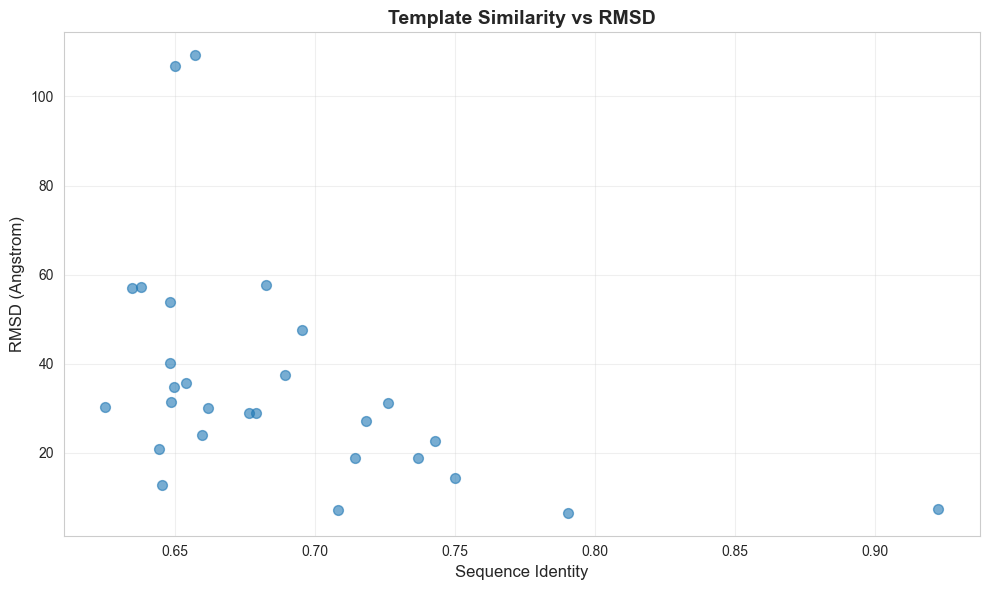

Correlation (Sequence Identity vs RMSD): -0.459
Good: Higher sequence identity leads to lower RMSD


In [17]:
# Sequence identity vs RMSD scatter plot
if 'seq_identity' in df.columns and 'mean_rmsd' in df.columns and df['mean_rmsd'].notna().any():
    plt.figure(figsize=(10, 6))
    plt.scatter(df['seq_identity'], df['mean_rmsd'], alpha=0.6, s=50)
    plt.xlabel('Sequence Identity', fontsize=12)
    plt.ylabel('RMSD (Angstrom)', fontsize=12)
    plt.title('Template Similarity vs RMSD', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    valid_data = df[['seq_identity', 'mean_rmsd']].dropna()
    if len(valid_data) > 1:
        corr = valid_data.corr().iloc[0, 1]
        print(f'Correlation (Sequence Identity vs RMSD): {corr:.3f}')
        
        if corr < -0.3:
            print('Good: Higher sequence identity leads to lower RMSD')
        elif corr > 0.3:
            print('Warning: Positive correlation detected - investigate')
        else:
            print('Warning: Weak correlation - template selection can be improved')
else:
    print('Sequence identity or RMSD data not available')

## セクション3: 処理ステップの効果

Local Alignment Usage: 0/28 (0.0%)
Kabsch Application: 19/28 (67.9%)


/var/folders/ym/rx96cfsj6ndcpfp31kb6f23h0000gn/T/ipykernel_56033/2459153595.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_to_plot, labels=['No Local Align', 'Used Local Align'])
/var/folders/ym/rx96cfsj6ndcpfp31kb6f23h0000gn/T/ipykernel_56033/2459153595.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['No Kabsch', 'Kabsch Applied'])


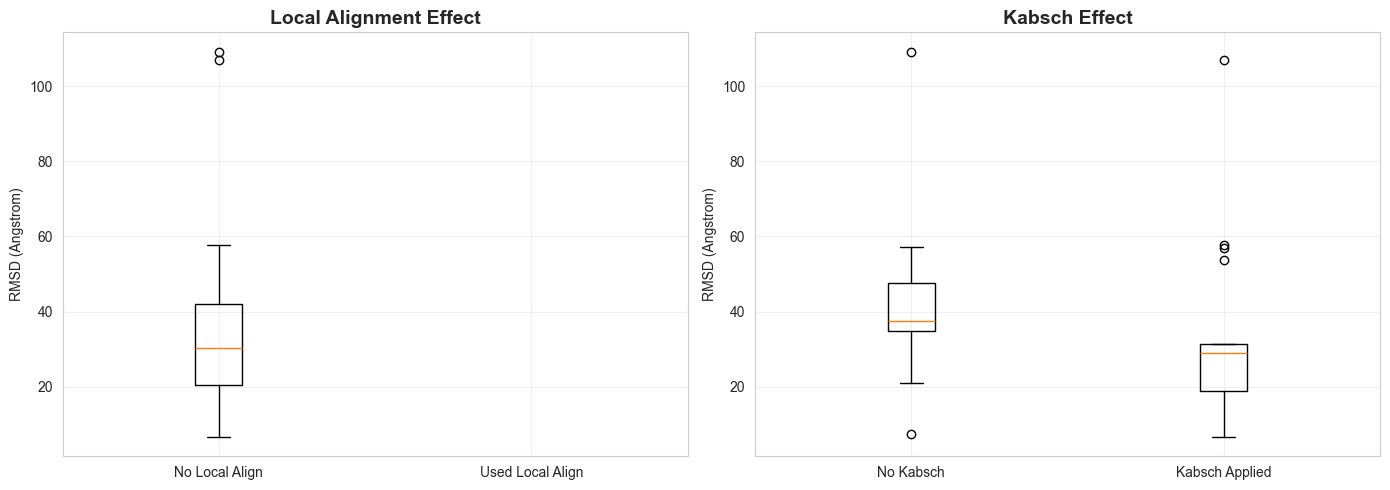

In [18]:
# Local alignment and Kabsch effects
if 'mean_rmsd' in df.columns and df['mean_rmsd'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Local alignment effect
    if 'used_local_align' in df.columns:
        data_to_plot = [df[df['used_local_align'] == False]['mean_rmsd'].dropna(),
                        df[df['used_local_align'] == True]['mean_rmsd'].dropna()]
        axes[0].boxplot(data_to_plot, labels=['No Local Align', 'Used Local Align'])
        axes[0].set_title('Local Alignment Effect', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('RMSD (Angstrom)')
        axes[0].grid(True, alpha=0.3)
        
        # Print usage statistics
        local_count = df['used_local_align'].sum()
        total_count = len(df)
        print(f'Local Alignment Usage: {local_count}/{total_count} ({100*local_count/total_count:.1f}%)')
    
    # Kabsch effect
    if 'kabsch_applied' in df.columns:
        data_to_plot = [df[df['kabsch_applied'] == False]['mean_rmsd'].dropna(),
                        df[df['kabsch_applied'] == True]['mean_rmsd'].dropna()]
        axes[1].boxplot(data_to_plot, labels=['No Kabsch', 'Kabsch Applied'])
        axes[1].set_title('Kabsch Effect', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('RMSD (Angstrom)')
        axes[1].grid(True, alpha=0.3)
        
        # Print usage statistics
        kabsch_count = df['kabsch_applied'].sum()
        print(f'Kabsch Application: {kabsch_count}/{total_count} ({100*kabsch_count/total_count:.1f}%)')
    
    plt.tight_layout()
    plt.show()
else:
    print('RMSD data not available for step analysis')

Coverage Improvement (Gap Filling):
  Mean:   0.000
  Median: 0.000
  Max:    0.000


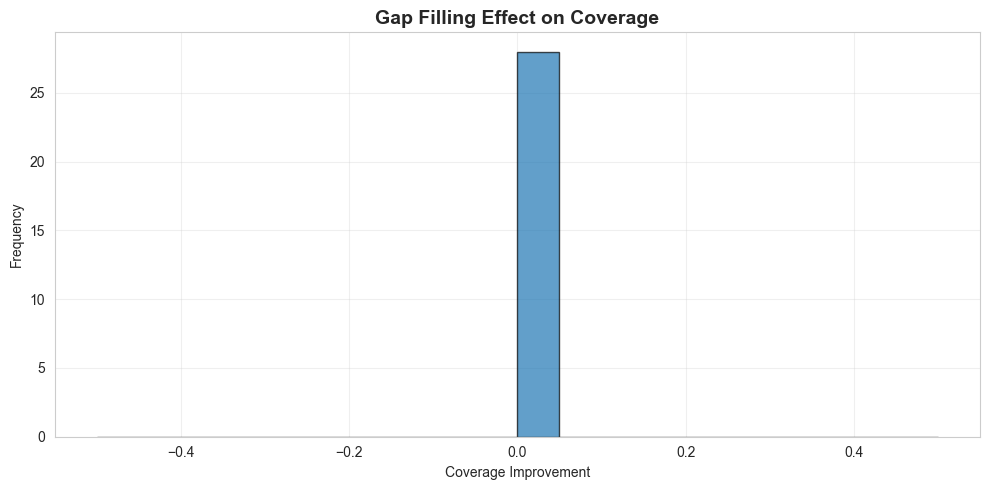

In [19]:
# Gap filling effectiveness
if 'raw_coverage' in df.columns and 'final_coverage' in df.columns:
    coverage_improvement = df['final_coverage'] - df['raw_coverage']
    print(f'Coverage Improvement (Gap Filling):')
    print(f'  Mean:   {coverage_improvement.mean():.3f}')
    print(f'  Median: {coverage_improvement.median():.3f}')
    print(f'  Max:    {coverage_improvement.max():.3f}')
    
    # Histogram of improvement
    plt.figure(figsize=(10, 5))
    plt.hist(coverage_improvement, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Coverage Improvement')
    plt.ylabel('Frequency')
    plt.title('Gap Filling Effect on Coverage', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## セクション4: 失敗ケースの特定

In [20]:
# Worst 5 cases
if 'mean_rmsd' in df.columns and df['mean_rmsd'].notna().any():
    worst_cases = df.nlargest(5, 'mean_rmsd')[[
        'query_id', 'query_length', 'mean_rmsd', 'seq_identity', 
        'raw_coverage', 'final_coverage', 'used_local_align', 'kabsch_applied'
    ]]
    
    print('='*80)
    print('WORST 5 CASES (Highest RMSD)')
    print('='*80)
    print(worst_cases.to_string(index=False))
    
    # Best 5 cases for comparison
    best_cases = df.nsmallest(5, 'mean_rmsd')[[
        'query_id', 'query_length', 'mean_rmsd', 'seq_identity', 
        'raw_coverage', 'final_coverage', 'used_local_align', 'kabsch_applied'
    ]]
    
    print('\n' + '='*80)
    print('BEST 5 CASES (Lowest RMSD)')
    print('='*80)
    print(best_cases.to_string(index=False))
else:
    print('RMSD data not available for failure analysis')

WORST 5 CASES (Highest RMSD)
query_id  query_length  mean_rmsd  seq_identity  raw_coverage  final_coverage  used_local_align  kabsch_applied
    9MME          4640 109.233749      0.657112      0.656681        0.656681             False           False
    9ZCC          1460 106.898556      0.649899      0.662329        0.662329             False            True
    9E74           255  57.660814      0.682353      0.682353        0.682353             False            True
    9JFO           195  57.321736      0.637681      0.538462        0.538462             False           False
    9LEL           476  56.997774      0.634454      0.634454        0.634454             False            True

BEST 5 CASES (Lowest RMSD)
query_id  query_length  mean_rmsd  seq_identity  raw_coverage  final_coverage  used_local_align  kabsch_applied
    9E9Q           101   6.579812      0.790323      0.970297        0.970297             False            True
    9OD4            23   7.302631      0.708333

## まとめ・次のアクション

このセクションに分析結果から得られた示唆を記載します。

### 主要な発見
- （ここに結果を記載）

### ボトルネック
- （ここに特定されたボトルネックを記載）

### 推奨される次のアクション
- （ここに改善策を記載）